## Towards understanding breadth of exploration during training.

Do we want an algorithm which explores it's environment and exploits found solutions or do we want an algorithm which **learns to explore**?
Currently, we're only concerned with exploring the training data distribution. I haven't really taken a look at the training performance, let's give that
a try.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
root = "/ptmp/rfechner/out/exp05_train_qwen2.5-7b/"
paths = [
    os.path.join(root, p, 'train_jsonl') for p in os.listdir(root)
]

In [5]:
with open(os.path.join(paths[0], '1_rollouts.jsonl'), 'r') as file:
    df = pd.read_json(file, lines=True)

### Vizualize solverate per training question over the course of training

In [9]:
def load_training_rollouts(path : str) -> pd.DataFrame:
    df_paths = os.listdir(path)
    df_paths = list(sorted(
        filter(lambda x: x.endswith('_rollouts.jsonl'), df_paths),
        key=lambda x: int(x.split('_')[0])
    ))
    assert len(df_paths) > 0
    df_paths = [os.path.join(path, p) for p in df_paths]
    dfs = []
    for dfpath in df_paths:
        with open(dfpath, 'r') as file:
            dfs.append(pd.read_json(file, lines=True))
    
    return pd.concat(dfs, axis=0)

In [10]:
df = load_training_rollouts(paths[0])

In [14]:
solverates = {}
for qname, group in df.groupby('input', sort=False):
    solverates[qname] = []
    for step, subgroup in group.groupby('step'):
        solverates[qname].append(np.mean(subgroup['score']))

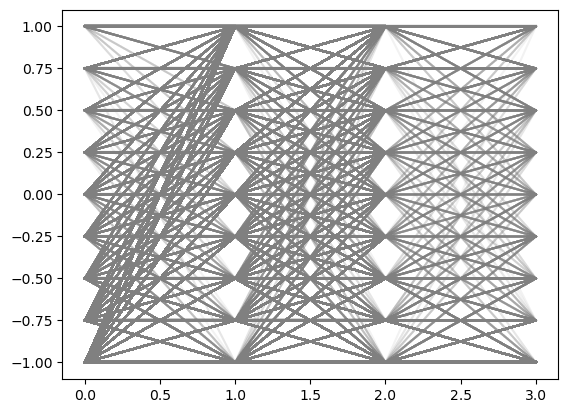

In [17]:
for k, v in solverates.items():
    plt.plot(v, color='gray', alpha=0.1)

plt.show()

In [18]:
srs = np.full(shape=(len(solverates), max([len(x) for x in solverates.values()])), fill_value=np.nan)
for i, v in enumerate(solverates.values()):
    srs[i, :len(v)] = np.array(v)

In [21]:
np.nanmean(srs, axis=0)

array([-0.77794701, -0.38689548, -0.29997022, -0.28085033])

#### Observation
A majority of the training questions isn't solved on average. Let's perhaps look at pass@8 instead to see whether a question is solved.

In [22]:
issolved = {}
for qname, group in df.groupby('input', sort=False):
    issolved[qname] = []
    for step, subgroup in group.groupby('step'):
        issolved[qname].append(np.max(subgroup['score']))

In [23]:
solved = np.full(shape=(len(issolved), max([len(x) for x in issolved.values()])), fill_value=np.nan)
for i, v in enumerate(issolved.values()):
    solved[i, :len(v)] = np.array(v)

In [24]:
np.nanmean(solved, axis=0)

array([-0.41385662,  0.17699617,  0.2308494 ,  0.24023505])

Okay, rather we have some questions which aren't ever solved. Looking at it this way we can more clearly see the trend. Can i take a look at how many questions aren't solved at all during training?

In [25]:
(np.nanmax(solved, axis=1) > 0).sum() / solved.shape[0]

np.float64(0.6935392462453953)

=> about 30 percent of questions in the training set are never solved.

In [37]:
paths

['/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__gspo/train_jsonl',
 '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__entropy_reg/train_jsonl',
 '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__gtpo/train_jsonl',
 '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__drgrpo/train_jsonl',
 '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__grpo-s/train_jsonl',
 '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__grpo/train_jsonl',
 '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__clip-cov/train_jsonl',
 '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__kl-cov/train_jsonl',
 '/ptmp/rfechner/out/exp05_train_qwen2.5-7b/qwen2.5_7b__dapo/train_jsonl']

In [ ]:
overall_solved = {}
from tqdm import tqdm
for dfpath in tqdm(paths):
    method = dfpath.split('/')[-2].split('__')[-1]
    try:
        df = load_training_rollouts(dfpath)
    except:
        print(f"Failed: {method}")
        continue
    issolved = {}
    for qname, group in df.groupby('input', sort=False):
        issolved[qname] = []
        for step, subgroup in group.groupby('step'):
            issolved[qname].append(np.max(subgroup['score']))
    solved = np.full(shape=(len(issolved), max([len(x) for x in issolved.values()])), fill_value=np.nan)
    for i, v in enumerate(issolved.values()):
        solved[i, :len(v)] = np.array(v)
    overall_solved[method] = solved

 67%|██████▋   | 6/9 [02:21<01:08, 22.79s/it]

Failed: clip-cov
Failed: kl-cov


100%|██████████| 9/9 [02:32<00:00, 16.91s/it]


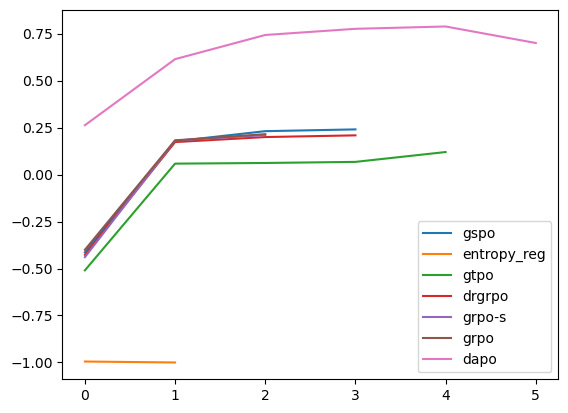

In [30]:
for method, solved in overall_solved.items():
    vs = np.nanmean(solved, axis=0)
    plt.plot(vs, label=method)
plt.legend()
plt.show()

In [32]:
for name, s in overall_solved.items():
    print(f"Method: {name}, number of questions: {len(s)}")

Method: gspo, number of questions: 14116
Method: entropy_reg, number of questions: 13919
Method: gtpo, number of questions: 14116
Method: drgrpo, number of questions: 14116
Method: grpo-s, number of questions: 14115
Method: grpo, number of questions: 14115
Method: dapo, number of questions: 9163


DAPO is pushed up because we're only saving rollouts for which we do solve already.

Method: gspo, num questions never solved: [9979 5803 5166 1099]
Method: entropy_reg, num questions never solved: [13884  4513]
Method: gtpo, num questions never solved: [10656  6648  6617  6333  3333]
Method: drgrpo, num questions never solved: [10074  5834  5476  2666]
Method: grpo-s, num questions never solved: [10159  5711  3882]
Method: grpo, num questions never solved: [9884 5721 4244]
Method: dapo, num questions never solved: [3379 1194  388   97   14    3]


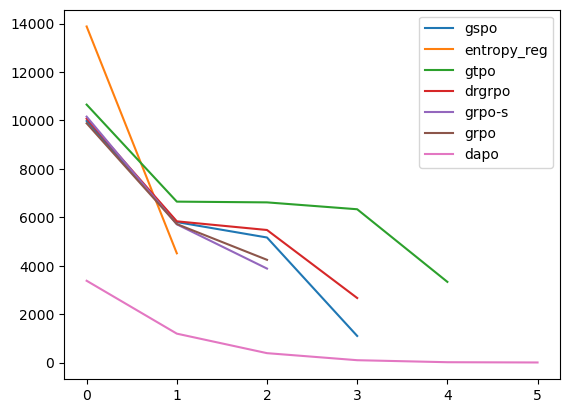

In [36]:
# Could i plot the number of questions which are never solved?
for method, solved in overall_solved.items():
    not_solved = solved == -1
    not_solved_count = not_solved.sum(axis=0)
    print(f"Method: {method}, num questions never solved: {not_solved_count}")
    plt.plot(not_solved_count, label=method)
plt.legend()
plt.show()

DAPO number of never solved questions seems weird. It should always be zero, because dapo doesn't accept zero-std groups.

Thought: In DAPO, we keep on sampling. However: If making an error on a very easy question is more likely than solving a very hard question, we never make progress on hard questions. Instead, we keep on sharpening easier questions until in the limit solving hard questions becomes more likely (which it might not every get to).

I'm sure people are already doing curriculum learning, but could I just quickly design my own:
- make a mapper from question to solverate
- every training rollout we update the solverates with a running mean
- in case scores are > -0.5 this means that we solve the question 1/4th of the times we're asked, which is likely enough.
- flag these questions and remove them from the dataloader by dropping the rows in the training dataset which correspond to the already solved questions
- problem: we're then dropping rows from the dataframe we're iterating over. This means: we should rather keep a list of dropping indeces. Next iteration of the training loader we can just drop the columns before the `__iter__` call.

### Actual embeddings analysis...

Okay, now let's think about the embeddings of the responses for each method. Over the course of training, the same questions are answered multiple times until they're answered correctly once, at which point the algorithm focuses in on the found solution.

We could vizualize the breadth of embeddings of questions per step (number of clusters, variance measures?)